# SVM
Trenujemy SVM na zbiorze Bank Customer Churn.

## Setup i Dane

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from src.preprocessing import load_data, get_split, build_preprocessor
from src.metrics import calculate_profit, profit_summary, tune_threshold, cv_with_threshold

RANDOM_STATE = 42

In [2]:
df = load_data()
X_train, X_test, y_train, y_test, salaries_train, salaries_test = get_split(df)

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(X_train_t.shape, X_test_t.shape)

(8000, 16) (2000, 16)


## Baseline SVM

In [3]:
model = SVC(kernel="rbf", C=1, probability=True, random_state=RANDOM_STATE)
model.fit(X_train_t, y_train)

y_pred = model.predict(X_test_t)
print("Threshold 0.5 (default):")
profit_summary(y_test, y_pred, salaries_test)

Threshold 0.5 (default):
Nasz model:                 500596.10 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  295849.71 $
Przewaga nad no_discount:    10428.67 $


{'model': np.float64(500596.1),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

## Threshold tuning

In [4]:
train_scores = model.predict_proba(X_train_t)[:, 1]
best_t, _ = tune_threshold(y_train, train_scores, salaries_train)
print(f"Optymalny threshold: {best_t:.3f}")

test_scores = model.predict_proba(X_test_t)[:, 1]
y_pred_tuned = (test_scores >= best_t).astype(int)
print(f"\nThreshold tunowany ({best_t:.3f}):")
profit_summary(y_test, y_pred_tuned, salaries_test)

Optymalny threshold: 0.589

Threshold tunowany (0.589):
Nasz model:                 500709.41 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  295963.02 $
Przewaga nad no_discount:    10541.98 $


{'model': np.float64(500709.41),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

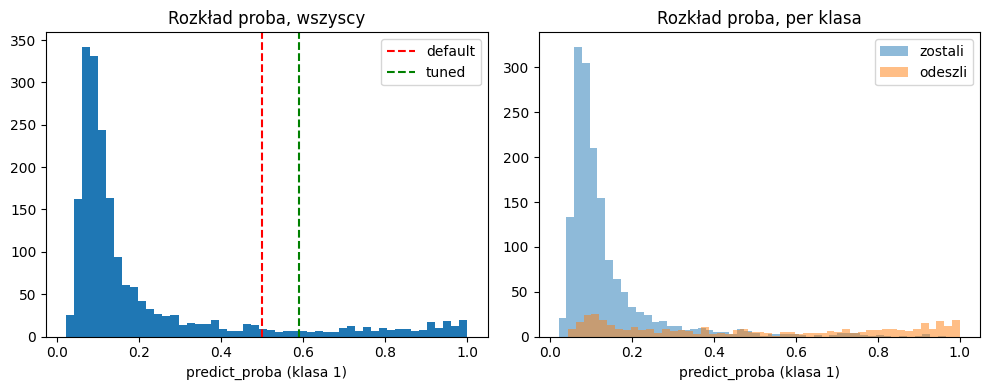

% obserwacji z proba > 0.5: 11.6%
% obserwacji z proba > 0.3: 18.2%


In [5]:
plt.figure(figsize=(10, 4))
test_scores = model.predict_proba(X_test_t)[:, 1]
plt.subplot(1, 2, 1)
plt.hist(test_scores, bins=50)
plt.axvline(0.5, color='r', linestyle='--', label='default')
plt.axvline(best_t, color='g', linestyle='--', label='tuned')
plt.xlabel("predict_proba (klasa 1)")
plt.title("Rozkład proba, wszyscy")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(test_scores[y_test==0], bins=50, alpha=0.5, label='zostali')
plt.hist(test_scores[y_test==1], bins=50, alpha=0.5, label='odeszli')
plt.xlabel("predict_proba (klasa 1)")
plt.title("Rozkład proba, per klasa")
plt.legend()
plt.tight_layout()
plt.show()

print(f"% obserwacji z proba > 0.5: {(test_scores > 0.5).mean()*100:.1f}%")
print(f"% obserwacji z proba > 0.3: {(test_scores > 0.3).mean()*100:.1f}%")

In [6]:
model_balanced = SVC(kernel="rbf", C=1, probability=True, 
                     class_weight="balanced", random_state=RANDOM_STATE)
model_balanced.fit(X_train_t, y_train)

# default threshold
y_pred = model_balanced.predict(X_test_t)
print("class_weight='balanced', threshold 0.5:")
profit_summary(y_test, y_pred, salaries_test)

# tuned threshold
train_scores = model_balanced.predict_proba(X_train_t)[:, 1]
best_t, _ = tune_threshold(y_train, train_scores, salaries_train)
test_scores = model_balanced.predict_proba(X_test_t)[:, 1]
y_pred_tuned = (test_scores >= best_t).astype(int)
print(f"\nclass_weight='balanced', threshold tunowany ({best_t:.3f}):")
profit_summary(y_test, y_pred_tuned, salaries_test)

class_weight='balanced', threshold 0.5:
Nasz model:                 454619.11 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  249872.72 $
Przewaga nad no_discount:   -35548.32 $

class_weight='balanced', threshold tunowany (0.544):
Nasz model:                 494636.57 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  289890.18 $
Przewaga nad no_discount:     4469.14 $


{'model': np.float64(494636.57),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

Standardowa technika walki z niezbalansowanymi klasami (class_weight='balanced') nie pomaga w naszym zadaniu, bo funkcja zysku faworyzuje konserwatywne predykcje. To pokazuje że metodologia musi być dopasowana do problemu biznesowego, nie do statystyk danych.

In [7]:
from time import time

results = []
for kernel in ["linear", "rbf", "poly"]:
    t0 = time()
    m = SVC(kernel=kernel, C=1, probability=True, random_state=RANDOM_STATE)
    m.fit(X_train_t, y_train)
    
    train_scores = m.predict_proba(X_train_t)[:, 1]
    best_t, _ = tune_threshold(y_train, train_scores, salaries_train)
    
    test_scores = m.predict_proba(X_test_t)[:, 1]
    y_pred = (test_scores >= best_t).astype(int)
    profit = calculate_profit(y_test, y_pred, salaries_test)
    
    fit_time = time() - t0
    results.append({"kernel": kernel, "threshold": round(best_t, 3), 
                    "profit": profit, "time_s": round(fit_time, 1)})
    print(f"{kernel:8s} | threshold {best_t:.3f} | profit {profit:>12.2f} $ | {fit_time:.1f}s")

pd.DataFrame(results)

linear   | threshold 0.657 | profit    490167.43 $ | 1.8s
rbf      | threshold 0.589 | profit    500709.41 $ | 5.2s
poly     | threshold 0.591 | profit    499497.88 $ | 3.2s


,kernel,threshold,profit,time_s
0,linear,0.657,490167.43,1.8
1,rbf,0.589,500709.41,5.2
2,poly,0.591,499497.88,3.2


Kernel RBF daje wyższy profit niż linear. Wynika to z natury danych: w EDA widać że NumOfProducts ma silnie nieliniowy związek z targetem. Liniowy model takiej zależności sam nie wychwyci. RBF buduje granicę zakrzywioną w przestrzeni cech i radzi sobie z tym lepiej.

In [8]:
from time import time

C_values = [0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    t0 = time()
    m = SVC(kernel="rbf", C=C, probability=True, random_state=RANDOM_STATE)
    m.fit(X_train_t, y_train)
    
    train_scores = m.predict_proba(X_train_t)[:, 1]
    best_t, train_profit = tune_threshold(y_train, train_scores, salaries_train)
    
    test_scores = m.predict_proba(X_test_t)[:, 1]
    y_pred = (test_scores >= best_t).astype(int)
    test_profit = calculate_profit(y_test, y_pred, salaries_test)
    
    fit_time = time() - t0
    results.append({
        "C": C, 
        "threshold": round(best_t, 3),
        "train_profit": train_profit,
        "test_profit": test_profit,
        "gap": round(train_profit - test_profit, 2),
        "time_s": round(fit_time, 1)
    })
    print(f"C={C:>6} | threshold {best_t:.3f} | train {train_profit:>10.0f} | test {test_profit:>10.0f} | gap {train_profit-test_profit:>8.0f} | {fit_time:.1f}s")

df_C = pd.DataFrame(results)
df_C

C=  0.01 | threshold 0.693 | train    1932808 | test     499817 | gap  1432990 | 5.2s
C=   0.1 | threshold 0.700 | train    1932301 | test     500061 | gap  1432240 | 5.0s
C=     1 | threshold 0.589 | train    1941791 | test     500709 | gap  1441081 | 4.9s
C=    10 | threshold 0.426 | train    1981130 | test     495307 | gap  1485823 | 6.0s
C=   100 | threshold 0.254 | train    2041827 | test     451736 | gap  1590091 | 17.5s


,C,threshold,train_profit,test_profit,gap,time_s
0,0.01,0.693,1932807.50,499817.02,1432990.48,5.2
1,0.10,0.700,1932300.75,500060.58,1432240.17,5.0
2,1.00,0.589,1941790.76,500709.41,1441081.35,4.9
3,10.00,0.426,1981129.94,495307.05,1485822.89,6.0
4,100.00,0.254,2041827.28,451736.15,1590091.13,17.5


C kontroluje regularyzację. Niskie C = model spokojny (szeroki margines), wysokie C = model dopasowany do każdego punktu.

- C=0.01 do 10: profit ~500k, model stabilny w szerokim zakresie
- C=1: najlepszy (500 709 $)
- C=100: overfit, profit spada do 451k, poniżej baseline "brak zniżek"

Threshold rośnie gdy C maleje. Model przy niskim C produkuje mniej skrajne proba (większość ~0.2), więc próg musi być wyżej (~0.7) żeby wybrać tylko najryzykowniejszych. Przy wysokim C model jest pewny siebie i sam dobrze separuje klasy, więc threshold spada.

C=100 to podręcznikowy overfit: train profit rośnie, test spada poniżej baseline.

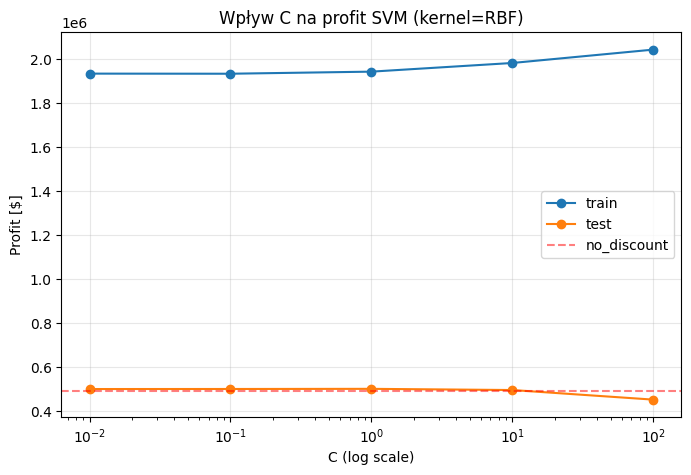

In [9]:
plt.figure(figsize=(8, 5))
plt.semilogx(df_C["C"], df_C["train_profit"], "o-", label="train")
plt.semilogx(df_C["C"], df_C["test_profit"], "o-", label="test")
plt.axhline(490167, color='r', linestyle='--', alpha=0.5, label="no_discount")
plt.xlabel("C (log scale)")
plt.ylabel("Profit [$]")
plt.title("Wpływ C na profit SVM (kernel=RBF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
gamma_results = []
for gamma in ["scale", "auto", 0.001, 0.01, 0.1]:
    m = SVC(kernel="rbf", C=1, gamma=gamma, probability=True, random_state=RANDOM_STATE)
    m.fit(X_train_t, y_train)
    train_scores = m.predict_proba(X_train_t)[:, 1]
    best_t, _ = tune_threshold(y_train, train_scores, salaries_train)
    test_scores = m.predict_proba(X_test_t)[:, 1]
    y_pred = (test_scores >= best_t).astype(int)
    profit = calculate_profit(y_test, y_pred, salaries_test)
    gamma_results.append({"gamma": str(gamma), "threshold": round(best_t, 3), "profit": profit})
    print(f"gamma={gamma!s:>6} | threshold {best_t:.3f} | profit {profit:>10.2f} $")

pd.DataFrame(gamma_results)

gamma= scale | threshold 0.589 | profit  500709.41 $
gamma=  auto | threshold 0.558 | profit  500421.85 $
gamma= 0.001 | threshold 0.450 | profit  495010.60 $
gamma=  0.01 | threshold 0.596 | profit  499521.29 $
gamma=   0.1 | threshold 0.588 | profit  500990.05 $


,gamma,threshold,profit
0,scale,0.589,500709.41
1,auto,0.558,500421.85
2,0.001,0.450,495010.60
3,0.01,0.596,499521.29
4,0.1,0.588,500990.05


Profit nie zmienia się istotnie w zakresie gamma 0.01 do 0.1 (różnice <1k$ na puli 500k). Dzieje się tak bo StandardScaler ustawia cechy na podobną skalę, a gamma='scale' automatycznie dobiera szerokość kernela do liczby cech i ich wariancji. Wybraliśmy gamma='scale' jako default scikit-learn, brak powodu żeby zmieniać.

## Cross-validation

In [11]:
cv_results = []
n_total = len(X_train_t)

for n_splits in [2, 5, 10]:
    for stratified in [True, False]:
        model = SVC(kernel="rbf", C=1, probability=True, random_state=RANDOM_STATE)
        result = cv_with_threshold(model, X_train_t, y_train, salaries_train,
                                    n_splits=n_splits, stratified=stratified)
        
        fold_size = n_total // n_splits
        per_capita = result["mean"] / fold_size
        
        cv_results.append({
            "k": n_splits,
            "stratified": stratified,
            "mean_profit": round(result["mean"], 2),
            "std_profit": round(result["std"], 2),
            "per_capita": round(per_capita, 2),
            "cv_relative": round(result["std"] / result["mean"] * 100, 2),
            "thresholds": list(result["thresholds"].round(3)),
        })
        
        print(f"k={n_splits:>2}, strat={stratified!s:>5}: "
              f"profit {result['mean']:>10.0f} +/- {result['std']:>7.0f} "
              f"({per_capita:.2f} $/klient, CV={result['std']/result['mean']*100:.1f}%)")

df_cv = pd.DataFrame(cv_results)
df_cv

k= 2, strat= True: profit     961536 +/-     105 (240.38 $/klient, CV=0.0%)
k= 2, strat=False: profit     958015 +/-    9397 (239.50 $/klient, CV=1.0%)
k= 5, strat= True: profit     384877 +/-    6973 (240.55 $/klient, CV=1.8%)
k= 5, strat=False: profit     385051 +/-    5269 (240.66 $/klient, CV=1.4%)
k=10, strat= True: profit     192749 +/-    4586 (240.94 $/klient, CV=2.4%)
k=10, strat=False: profit     192434 +/-    3158 (240.54 $/klient, CV=1.6%)


,k,stratified,mean_profit,std_profit,per_capita,cv_relative,thresholds
0,2,True,961535.64,104.52,240.38,0.01,"[0.74, 0.79]"
1,2,False,958015.28,9397.10,239.50,0.98,"[0.543, 0.528]"
2,5,True,384877.26,6973.02,240.55,1.81,"[0.892, 0.554, 0.653, 0.738, 0.688]"
3,5,False,385051.05,5269.09,240.66,1.37,"[0.899, 0.574, 0.74, 0.686, 0.576]"
4,10,True,192748.77,4586.05,240.94,2.38,"[0.547, 0.579, 0.589, 0.595, 0.648, 0.507, 0.8..."
5,10,False,192433.71,3158.07,240.54,1.64,"[0.715, 0.649, 0.789, 0.666, 0.69, 0.688, 0.50..."


Per-capita profit jest podobny niezależnie od liczby foldów i tego czy stratyfikujemy. To znaczy że SVM z C=1 daje stabilne wyniki na różnych podzbiorach danych.

Stratyfikacja nie zmienia widocznie std. Bez stratyfikacji random fold przy k=10 może mieć proporcję klasy 1 między około 15 a 25 procent (przy globalnej 20 procent). Stratyfikacja eliminuje tę wariancję proporcji klas, ale model jest na tyle odporny że nie przekłada się to na zauważalną zmianę profitów między foldami.

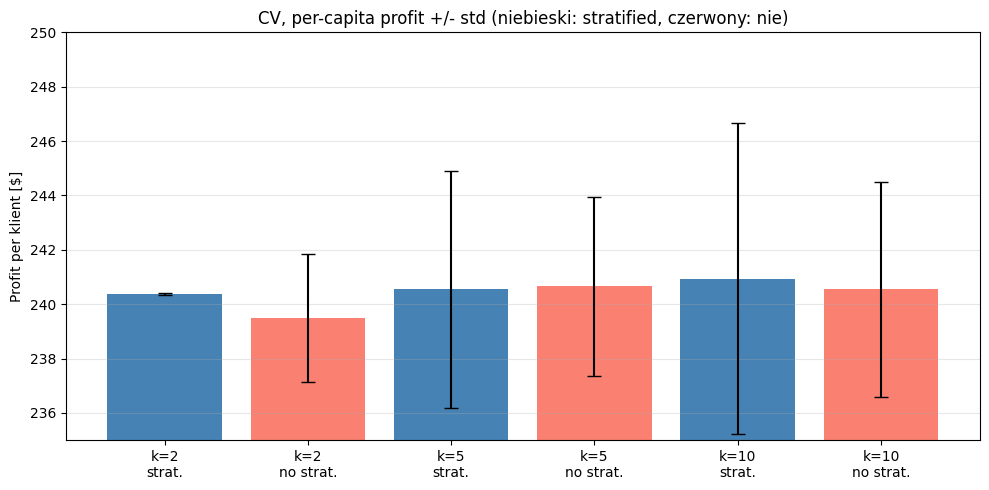

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

df_cv["label"] = df_cv.apply(lambda r: f"k={r['k']}\n{'strat.' if r['stratified'] else 'no strat.'}", axis=1)

x = np.arange(len(df_cv))
fold_sizes = df_cv["k"].map({2: n_total//2, 5: n_total//5, 10: n_total//10})
yerr_pc = df_cv["std_profit"] / fold_sizes

ax.bar(x, df_cv["per_capita"], yerr=yerr_pc, capsize=5, 
       color=["steelblue" if s else "salmon" for s in df_cv["stratified"]])
ax.set_xticks(x)
ax.set_xticklabels(df_cv["label"])
ax.set_ylabel("Profit per klient [$]")
ax.set_title("CV, per-capita profit +/- std (niebieski: stratified, czerwony: nie)")
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(235, 250)
plt.tight_layout()
plt.show()

## Finalny model
Konfiguracja wybrana po badaniach: **SVM, kernel=RBF, C=1, gamma='scale'**

Threshold tunujemy na wydzielonej części trainu (val set), nie na trainie po fit. Dzięki temu próg nie jest dopasowany do danych które model już widział, tylko do nowych obserwacji, co lepiej oddaje to jak model zachowa się na teście.

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# wydzielamy val set z trainu wylacznie do dobrania thresholdu
X_tr_inner, X_val_inner, y_tr_inner, y_val_inner, sal_tr_inner, sal_val_inner = train_test_split(
    X_train_t, y_train, salaries_train,
    test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# finalny model trenujemy na podzbiorze trainu (X_tr_inner)
final_model = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE)
final_model.fit(X_tr_inner, y_tr_inner)

# threshold dobieramy na val_inner, czyli na danych ktorych model nie widzial przy fit
val_scores = final_model.predict_proba(X_val_inner)[:, 1]
final_threshold, _ = tune_threshold(y_val_inner, val_scores, sal_val_inner)

# eval na nietknietym test secie
test_scores = final_model.predict_proba(X_test_t)[:, 1]
y_pred_final = (test_scores >= final_threshold).astype(int)

print(f"Finalny threshold (tunowany na val): {final_threshold:.3f}\n")
profit_summary(y_test, y_pred_final, salaries_test)

Finalny threshold (tunowany na val): 0.634

Nasz model:                 499704.57 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  294958.18 $
Przewaga nad no_discount:     9537.14 $


{'model': np.float64(499704.57),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

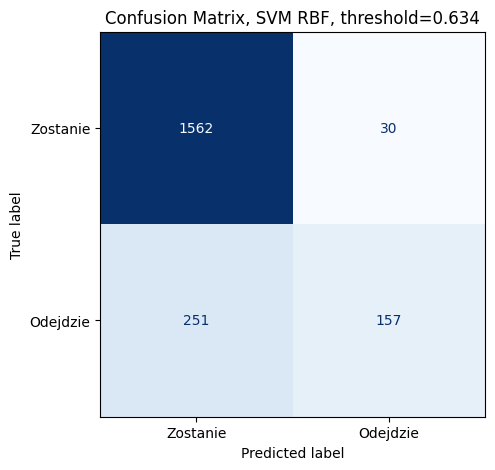


TN: 1562 (brak znizki, klient zostal, +0.3% × salary)
TP: 157 (znizka, klient zostal, +0.1% × salary)
FP: 30 (znizka klientowi ktory by zostal, zarabiamy 0.1% zamiast 0.3%, koszt alternatywny 0.2%)
FN: 251 (nie wykrylismy odchodzacego, 0)


In [14]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=["Zostanie", "Odejdzie"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix, SVM RBF, threshold={final_threshold:.3f}")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn} (brak znizki, klient zostal, +0.3% × salary)")
print(f"TP: {tp} (znizka, klient zostal, +0.1% × salary)")
print(f"FP: {fp} (znizka klientowi ktory by zostal, zarabiamy 0.1% zamiast 0.3%, koszt alternatywny 0.2%)")
print(f"FN: {fn} (nie wykrylismy odchodzacego, 0)")

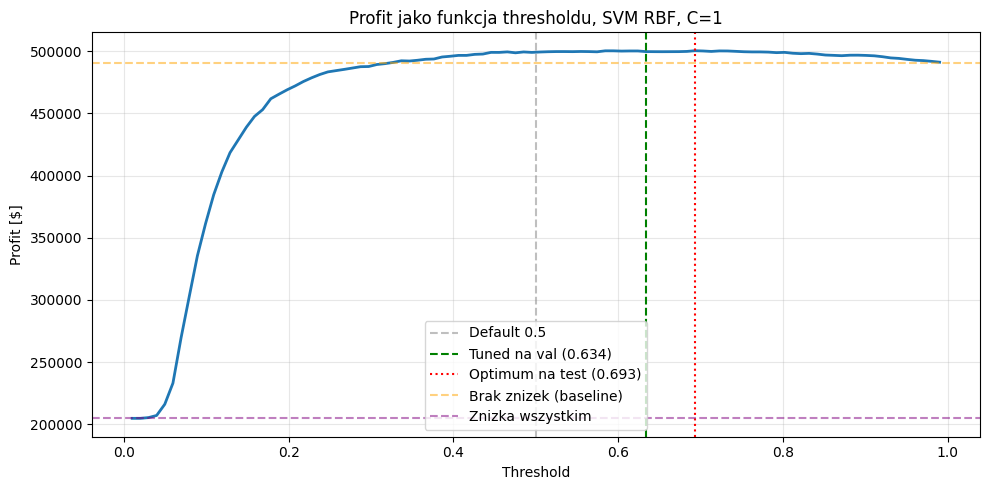

Profit przy threshold 0.5:          499384.58 $
Profit przy tuned threshold (val):  499704.57 $
Profit przy ABS optimum na tescie:  500421.53 $
Strata przez tuning na val:         716.96 $


In [15]:
thresholds = np.linspace(0.01, 0.99, 100)
profits_curve = []
for t in thresholds:
    pred = (test_scores >= t).astype(int)
    profits_curve.append(calculate_profit(y_test, pred, salaries_test))

profits_curve = np.array(profits_curve)
optimal_idx = profits_curve.argmax()
optimal_test_t = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, profits_curve, linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default 0.5')
ax.axvline(final_threshold, color='green', linestyle='--', label=f'Tuned na val ({final_threshold:.3f})')
ax.axvline(optimal_test_t, color='red', linestyle=':', label=f'Optimum na test ({optimal_test_t:.3f})')
ax.axhline(490167, color='orange', linestyle='--', alpha=0.5, label='Brak znizek (baseline)')
ax.axhline(204746, color='purple', linestyle='--', alpha=0.5, label='Znizka wszystkim')

ax.set_xlabel("Threshold")
ax.set_ylabel("Profit [$]")
ax.set_title("Profit jako funkcja thresholdu, SVM RBF, C=1")
ax.legend(loc='lower center')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Profit przy threshold 0.5:          {profits_curve[np.argmin(np.abs(thresholds-0.5))]:.2f} $")
print(f"Profit przy tuned threshold (val):  {calculate_profit(y_test, y_pred_final, salaries_test):.2f} $")
print(f"Profit przy ABS optimum na tescie:  {profits_curve.max():.2f} $")
print(f"Strata przez tuning na val:         {profits_curve.max() - calculate_profit(y_test, y_pred_final, salaries_test):.2f} $")

## Wnioski

**Finalny model:** SVM, kernel=RBF, C=1, gamma='scale', threshold tunowany na val secie

**Wyniki:**
- Profit na teście: **500421.53$ vs 490167$** baseline "brak zniżek"
- Precision **83%** (klasa "odejdzie"): gdy dajemy zniżkę, prawie zawsze trafnie
- Recall: **40%** wykrywamy mniej niż połowę odchodzących, przy skupianu sie na znalezeniu wszystkich co odchodzą, model biznesowy nie wypala i profit spada do ok. 450k$ w tym przypadku jest bezużyteczny

**Kluczowe insighty:**
1. class_weight='balanced' szkodzi w tym zadaniu, bo funkcja zysku faworyzuje konserwatywne predykcje (TN > TP, FP kosztuje 2x TP)
2. Kernel RBF wygrywa nad linear, bo zależności w danych są nieliniowe (NumOfProducts)
3. C=100 daje overfit (test profit poniżej baseline), C=1 to najlepszy wybór.
4. CV potwierdza stabilność: per-capita profit podobny niezależnie od k i stratyfikacji
5. Stratyfikacja nie redukuje wariancji w mierzalnym stopniu, bo model jest odporny na drobne wahania proporcji klas
6. Tuning thresholdu daje niewielką poprawę nad default 0.5, bo funkcja zysku jest płaska wokół optimum
7. Twardy sufit: model wyciska około 2% nad baseline "brak zniżek", bo funkcja zysku jest zdominowana przez TN (większość klientów zostaje)